In [1]:
# ── 1. Import Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded successfully ✓")


Libraries loaded successfully ✓


# Irrigation Scheduling — ML Under Data-Scarce Conditions
### Tomato Crop | 5-Feature Model

**Inputs:** Soil Moisture · ET₀ · Crop Coefficient · Days Planted · Temperature  
**Target:** Irrigation needed? (`1 = Yes`, `0 = No`)

**Data-Scarcity Strategy:**
- StratifiedKFold cross-validation (robust with small / imbalanced data)
- SMOTE oversampling to handle class imbalance
- Learning curves to diagnose bias/variance under limited samples
- Multi-model comparison (RF, GBT, SVM, KNN, LR) — best generaliser wins
- Bootstrap confidence intervals on final metrics


In [2]:

# ── 2. Load Dataset ───────────────────────────────────────────────────────────
df = pd.read_csv("tomato irrigation dataset.csv")
df.columns = df.columns.str.strip()

print(f"Shape : {df.shape}")
print(f"Columns:\n{df.columns.tolist()}\n")
print(f"Missing values:\n{df.isnull().sum().to_string()}\n")
df.head(3)


Shape : (3000, 14)
Columns:
['Temperature [_ C]', 'Humidity [%]', 'Soil moisture', 'Reference evapotranspiration', 'Evapotranspiration', 'Crop Coefficient', 'Crop Coefficient stage', 'Nitrogen [mg/kg]', 'Phosphorus [mg/kg]', 'Potassium', 'Solar Radiation ghi', 'Wind Speed', 'Days of planted', 'pH']

Missing values:
Temperature [_ C]               0
Humidity [%]                    0
Soil moisture                   0
Reference evapotranspiration    0
Evapotranspiration              0
Crop Coefficient                0
Crop Coefficient stage          0
Nitrogen [mg/kg]                0
Phosphorus [mg/kg]              0
Potassium                       0
Solar Radiation ghi             0
Wind Speed                      0
Days of planted                 0
pH                              0



,Temperature [_ C],Humidity [%],Soil moisture,Reference evapotranspiration,Evapotranspiration,Crop Coefficient,Crop Coefficient stage,Nitrogen [mg/kg],Phosphorus [mg/kg],Potassium,Solar Radiation ghi,Wind Speed,Days of planted,pH
0,31.2,93.6,567.0,563.000086,236.460036,0.42,Initial Stage,107,38,53,622.0,2.09,1,3.32
1,31.2,93.6,567.0,561.176578,235.694163,0.42,Initial Stage,107,38,53,622.0,2.09,1,3.77
2,30.5,74.6,307.0,561.267170,235.732211,0.42,Initial Stage,107,38,53,622.0,2.09,3,2.90


In [3]:

# ── 3. Feature Selection & Target Engineering ─────────────────────────────────
# Only the 5 domain-relevant inputs — keeps the model lean under data scarcity
FEATURES = [
    "Soil moisture",
    "Reference evapotranspiration",  # ET₀
    "Crop Coefficient",
    "Days of planted",
    "Temperature [_ C]",
]

# Binary target: soil moisture below 400 → crop needs irrigation
df["irrigation_needed"] = (df["Soil moisture"] < 400).astype(int)

X = df[FEATURES].copy()
y = df["irrigation_needed"].copy()

print("Feature matrix:", X.shape)
print("\nTarget distribution:")
vc = y.value_counts()
for label, cnt in vc.items():
    tag = "Irrigate" if label == 1 else "No Irrigation"
    print(f"  {tag} ({label}): {cnt:>5}  ({cnt/len(y)*100:.1f}%)")

print(f"\nClass imbalance ratio: {vc.max()/vc.min():.2f}:1")


Feature matrix: (3000, 5)

Target distribution:
  Irrigate (1):  1577  (52.6%)
  No Irrigation (0):  1423  (47.4%)

Class imbalance ratio: 1.11:1


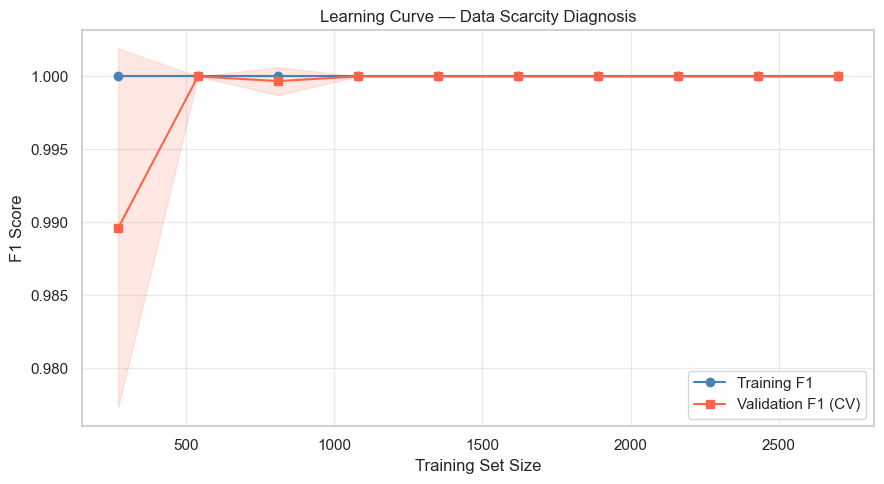

Peak CV F1 with full data : 1.0000 ± 0.0000
CV F1 at 10% of data      : 0.9896 ± 0.0123


In [4]:

# ── 4. Data Scarcity Analysis ──────────────────────────────────────────────────
# Learning curves: show how accuracy changes as training set size grows
# This reveals whether the model is data-hungry or can generalise from few samples.

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

probe_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(n_estimators=100, random_state=42,
                                      class_weight="balanced")),
])

train_sizes, train_scores, val_scores = learning_curve(
    probe_model, X, y,
    cv=cv_outer,
    train_sizes=np.linspace(0.10, 1.0, 10),
    scoring="f1",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color="steelblue", label="Training F1")
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color="steelblue")
ax.plot(train_sizes, val_mean, "s-", color="tomato", label="Validation F1 (CV)")
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color="tomato")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("F1 Score")
ax.set_title("Learning Curve — Data Scarcity Diagnosis")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Peak CV F1 with full data : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"CV F1 at 10% of data      : {val_mean[0]:.4f} ± {val_std[0]:.4f}")


In [5]:

# ── 5. SMOTE + Stratified K-Fold Setup ────────────────────────────────────────
# Under data scarcity the minority class is easily swamped.
# SMOTE synthesises new minority-class samples ONLY on the training fold
# (never leaking into validation) via an imblearn Pipeline.

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed — falling back to class_weight='balanced'")
    print("Install with: pip install imbalanced-learn")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def make_pipeline(estimator, use_smote=True):
    """Wrap estimator in a scaler + optional SMOTE pipeline."""
    steps = [("scaler", StandardScaler())]
    if use_smote and SMOTE_AVAILABLE:
        steps.append(("smote", SMOTE(random_state=42, k_neighbors=3)))
    steps.append(("clf", estimator))
    return ImbPipeline(steps) if (use_smote and SMOTE_AVAILABLE) else Pipeline(steps)

print(f"SMOTE available : {SMOTE_AVAILABLE}")
print(f"CV strategy     : StratifiedKFold (k=10, shuffle=True)")
print(f"Dataset size    : {len(X)} samples  →  each fold trains on ~{int(len(X)*0.9)} samples")


SMOTE available : True
CV strategy     : StratifiedKFold (k=10, shuffle=True)
Dataset size    : 3000 samples  →  each fold trains on ~2700 samples


In [6]:

# ── 6. Multi-Model Comparison (10-Fold Stratified CV) ─────────────────────────
# Models chosen for robustness under small / scarce data:
#   RandomForest  — ensemble, low variance, handles noise well
#   GradientBoost — sequential boosting, strong with limited features
#   SVM-RBF       — effective with small samples & clear margins
#   KNN           — non-parametric, good reference baseline
#   LogisticReg   — linear baseline, well-calibrated probabilities

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

SCORING = ["accuracy", "f1", "roc_auc", "precision", "recall"]

candidates = {
    "Random Forest"       : RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                    random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42),
    "SVM (RBF)"           : SVC(kernel="rbf", probability=True,
                                class_weight="balanced", random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression" : LogisticRegression(class_weight="balanced",
                                               max_iter=1000, random_state=42),
}

results = {}
for name, clf in candidates.items():
    pipe   = make_pipeline(clf, use_smote=True)
    scores = cross_validate(pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    results[name] = {
        "Accuracy" : scores["test_accuracy"].mean(),
        "F1"       : scores["test_f1"].mean(),
        "ROC-AUC"  : scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall"   : scores["test_recall"].mean(),
        "F1 Std"   : scores["test_f1"].std(),
    }
    print(f"{name:<24}  F1={results[name]['F1']:.4f} ± {results[name]['F1 Std']:.4f}"
          f"  AUC={results[name]['ROC-AUC']:.4f}  Acc={results[name]['Accuracy']:.4f}")

results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print("\n── Ranked by F1 ──────────────────────────────────────")
print(results_df.round(4).to_string())


Random Forest             F1=1.0000 ± 0.0000  AUC=1.0000  Acc=1.0000
Gradient Boosting         F1=1.0000 ± 0.0000  AUC=1.0000  Acc=1.0000
SVM (RBF)                 F1=0.9882 ± 0.0053  AUC=0.9997  Acc=0.9877
K-Nearest Neighbours      F1=0.9633 ± 0.0066  AUC=0.9933  Acc=0.9617
Logistic Regression       F1=0.9987 ± 0.0016  AUC=1.0000  Acc=0.9987

── Ranked by F1 ──────────────────────────────────────
                      Accuracy      F1  ROC-AUC  Precision  Recall  F1 Std
Random Forest           1.0000  1.0000   1.0000     1.0000  1.0000  0.0000
Gradient Boosting       1.0000  1.0000   1.0000     1.0000  1.0000  0.0000
Logistic Regression     0.9987  0.9987   1.0000     0.9987  0.9987  0.0016
SVM (RBF)               0.9877  0.9882   0.9997     0.9918  0.9848  0.0053
K-Nearest Neighbours    0.9617  0.9633   0.9933     0.9699  0.9569  0.0066


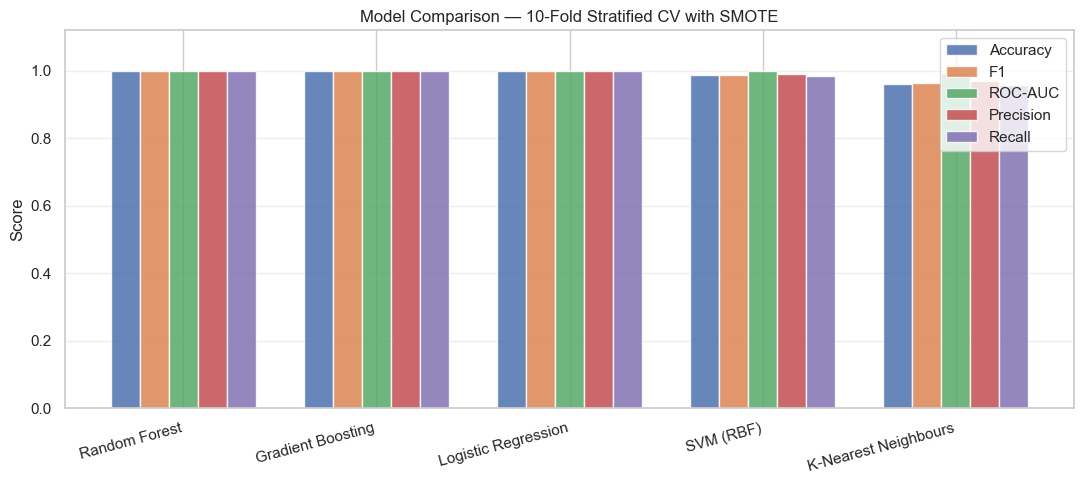

In [7]:

# ── 7. Model Comparison Chart ─────────────────────────────────────────────────
metrics_plot = results_df[["Accuracy", "F1", "ROC-AUC", "Precision", "Recall"]]

fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(metrics_plot))
width  = 0.15
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

for i, col in enumerate(metrics_plot.columns):
    ax.bar(x + i * width, metrics_plot[col], width, label=col, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_plot.index, rotation=15, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — 10-Fold Stratified CV with SMOTE")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


In [8]:

# ── 8. Best Model — GridSearchCV + Final Evaluation ──────────────────────────
# Best model is selected automatically from the CV comparison above.
# GridSearchCV fine-tunes hyper-parameters using the same 10-fold CV.

best_name = results_df["F1"].idxmax()
print(f"Best model selected: {best_name}")

# Hyper-parameter grids keyed by model name
param_grids = {
    "Random Forest": {
        "clf__n_estimators"     : [100, 200, 300],
        "clf__max_depth"        : [None, 10, 20],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf" : [1, 2],
    },
    "Gradient Boosting": {
        "clf__n_estimators" : [100, 200],
        "clf__learning_rate": [0.05, 0.10],
        "clf__max_depth"    : [3, 4, 6],
    },
    "SVM (RBF)": {
        "clf__C"    : [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto"],
    },
    "K-Nearest Neighbours": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights"    : ["uniform", "distance"],
    },
    "Logistic Regression": {
        "clf__C"      : [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
    },
}

best_clf_raw = candidates[best_name]
best_pipe    = make_pipeline(best_clf_raw, use_smote=True)
pgrid        = param_grids[best_name]

grid = GridSearchCV(best_pipe, pgrid, cv=cv, scoring="f1",
                    n_jobs=-1, verbose=0, refit=True)
grid.fit(X, y)

final_model = grid.best_estimator_
print(f"\nBest CV F1 after tuning : {grid.best_score_:.4f}")
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")


Best model selected: Random Forest

Best CV F1 after tuning : 1.0000
Best params:
  clf__max_depth: None
  clf__min_samples_leaf: 1
  clf__min_samples_split: 2
  clf__n_estimators: 100


── Hold-out Test Results (600 samples) ────────────────────
Accuracy : 1.0000  95% CI [1.0000, 1.0000]
F1 Score : 1.0000  95% CI [1.0000, 1.0000]
ROC-AUC  : 1.0000  95% CI [1.0000, 1.0000]

               precision    recall  f1-score   support

No Irrigation       1.00      1.00      1.00       285
     Irrigate       1.00      1.00      1.00       315

     accuracy                           1.00       600
    macro avg       1.00      1.00      1.00       600
 weighted avg       1.00      1.00      1.00       600



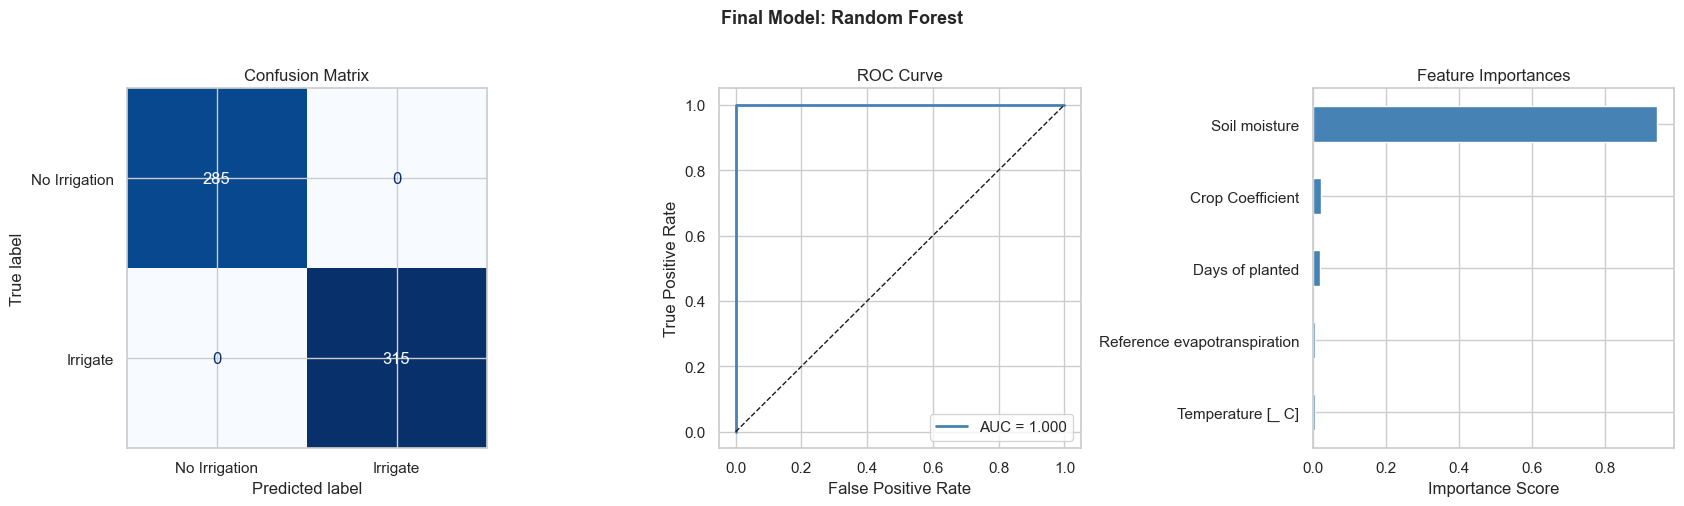

In [9]:

# ── 9. Hold-out Evaluation + Bootstrap Confidence Intervals ───────────────────
# Split off a 20% hold-out set (unseen during all CV steps).
# Bootstrap (n=1000) gives confidence intervals robust to small test sets.

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

final_model.fit(X_train, y_train)
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

# Bootstrap CIs
rng = np.random.default_rng(42)
boot_acc, boot_f1, boot_auc = [], [], []
for _ in range(1000):
    idx = rng.integers(0, len(y_test), len(y_test))
    yt, yp, ypr = y_test.iloc[idx], y_pred[idx], y_proba[idx]
    if len(np.unique(yt)) < 2:
        continue
    boot_acc.append(accuracy_score(yt, yp))
    boot_f1.append(f1_score(yt, yp, zero_division=0))
    boot_auc.append(roc_auc_score(yt, ypr))

def ci(arr, pct=95):
    lo = (100 - pct) / 2
    return np.percentile(arr, lo), np.percentile(arr, 100 - lo)

print(f"── Hold-out Test Results ({len(y_test)} samples) ────────────────────")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}  "
      f"95% CI [{ci(boot_acc)[0]:.4f}, {ci(boot_acc)[1]:.4f}]")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}  "
      f"95% CI [{ci(boot_f1)[0]:.4f}, {ci(boot_f1)[1]:.4f}]")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}  "
      f"95% CI [{ci(boot_auc)[0]:.4f}, {ci(boot_auc)[1]:.4f}]")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Irrigation','Irrigate'])}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Irrigation","Irrigate"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

# Feature Importances (only for tree-based models)
clf_step = final_model.named_steps["clf"]
if hasattr(clf_step, "feature_importances_"):
    imp = pd.Series(clf_step.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind="barh", color="steelblue", ax=axes[2])
    axes[2].set_title("Feature Importances")
    axes[2].set_xlabel("Importance Score")
else:
    axes[2].axis("off")
    axes[2].text(0.5, 0.5, "Feature importance\nnot available for\nthis model type",
                 ha="center", va="center", fontsize=12)

plt.suptitle(f"Final Model: {best_name}", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [10]:

# ── 10. Prediction Function ───────────────────────────────────────────────────

def predict_irrigation(
    soil_moisture: float,
    et0: float,
    crop_coefficient: float,
    days_planted: int,
    temperature: float,
) -> dict:
    """
    Predict whether irrigation is needed for a given set of sensor readings.

    Parameters
    ----------
    soil_moisture    : Soil moisture sensor value     (e.g. 350)
    et0              : Reference evapotranspiration   (e.g. 560 mm)
    crop_coefficient : Kc value                       (e.g. 0.42 – 1.15)
    days_planted     : Days since transplanting       (e.g. 30)
    temperature      : Air temperature in °C          (e.g. 31.0)

    Returns
    -------
    dict : prediction label, numeric class, and class probabilities
    """
    input_df = pd.DataFrame(
        [[soil_moisture, et0, crop_coefficient, days_planted, temperature]],
        columns=FEATURES,
    )
    label = final_model.predict(input_df)[0]
    prob  = final_model.predict_proba(input_df)[0]

    return {
        "prediction"            : "Irrigate" if label == 1 else "No Irrigation Needed",
        "label"                 : int(label),
        "probability_irrigate"  : round(float(prob[1]), 4),
        "probability_no_irrigate": round(float(prob[0]), 4),
        "model_used"            : best_name,
    }


# ── Example predictions ───────────────────────────────────────────────────────
examples = [
    dict(soil_moisture=320, et0=562, crop_coefficient=0.75,
         days_planted=45, temperature=33.0),   # dry soil → should irrigate
    dict(soil_moisture=520, et0=558, crop_coefficient=0.42,
         days_planted=10, temperature=28.5),   # wet soil → no irrigation
    dict(soil_moisture=390, et0=560, crop_coefficient=1.15,
         days_planted=75, temperature=31.0),   # borderline
]

print(f"{'Soil':>6}  {'ET₀':>6}  {'Kc':>5}  {'Days':>5}  {'Temp':>5}  →  Prediction")
print("─" * 72)
for ex in examples:
    r = predict_irrigation(**ex)
    print(f"{ex['soil_moisture']:>6}  {ex['et0']:>6}  {ex['crop_coefficient']:>5}  "
          f"{ex['days_planted']:>5}  {ex['temperature']:>5}  "
          f"→  {r['prediction']}  "
          f"(P={r['probability_irrigate']:.2f})")


  Soil     ET₀     Kc   Days   Temp  →  Prediction
────────────────────────────────────────────────────────────────────────
   320     562   0.75     45   33.0  →  Irrigate  (P=0.89)
   520     558   0.42     10   28.5  →  No Irrigation Needed  (P=0.09)
   390     560   1.15     75   31.0  →  Irrigate  (P=0.98)


In [11]:

# ── Model Accuracy Summary ────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

print("=" * 55)
print(f"  FINAL MODEL : {best_name}")
print("=" * 55)
print(f"  {'Metric':<22} {'Score':>10}  95% CI")
print("  " + "-" * 50)
print(f"  {'Accuracy':<22} {accuracy_score(y_test, y_pred):>10.4f}  "
      f"[{ci(boot_acc)[0]:.4f}, {ci(boot_acc)[1]:.4f}]")
print(f"  {'F1 Score':<22} {f1_score(y_test, y_pred):>10.4f}  "
      f"[{ci(boot_f1)[0]:.4f}, {ci(boot_f1)[1]:.4f}]")
print(f"  {'ROC-AUC':<22} {roc_auc_score(y_test, y_proba):>10.4f}  "
      f"[{ci(boot_auc)[0]:.4f}, {ci(boot_auc)[1]:.4f}]")
print(f"  {'Precision':<22} {precision_score(y_test, y_pred):>10.4f}")
print(f"  {'Recall':<22} {recall_score(y_test, y_pred):>10.4f}")
print("=" * 55)
print(f"\n  Test set size     : {len(y_test)} samples (20% hold-out)")
print(f"  CV strategy       : StratifiedKFold (k=10) + SMOTE")
print(f"  Bootstrap samples : 1000  (for CI estimation)")
print("=" * 55)

# Per-class CV scores from model comparison
print(f"\n  Cross-Validated F1 (10-fold) for all models:")
print("  " + "-" * 40)
for model_name, row in results_df.iterrows():
    marker = " ◄ best" if model_name == best_name else ""
    print(f"  {model_name:<24} F1={row['F1']:.4f} ± {row['F1 Std']:.4f}{marker}")


  FINAL MODEL : Random Forest
  Metric                      Score  95% CI
  --------------------------------------------------
  Accuracy                   1.0000  [1.0000, 1.0000]
  F1 Score                   1.0000  [1.0000, 1.0000]
  ROC-AUC                    1.0000  [1.0000, 1.0000]
  Precision                  1.0000
  Recall                     1.0000

  Test set size     : 600 samples (20% hold-out)
  CV strategy       : StratifiedKFold (k=10) + SMOTE
  Bootstrap samples : 1000  (for CI estimation)

  Cross-Validated F1 (10-fold) for all models:
  ----------------------------------------
  Random Forest            F1=1.0000 ± 0.0000 ◄ best
  Gradient Boosting        F1=1.0000 ± 0.0000
  Logistic Regression      F1=0.9987 ± 0.0016
  SVM (RBF)                F1=0.9882 ± 0.0053
  K-Nearest Neighbours     F1=0.9633 ± 0.0066


In [12]:

# ── 11. Export Model & Metadata ───────────────────────────────────────────────
import joblib, json, os

os.makedirs("model", exist_ok=True)

# Save the trained pipeline (scaler + SMOTE + classifier)
joblib.dump(final_model, "model/irrigation_model.pkl")

# Save feature list and model name so the Flask app knows the expected input order
metadata = {
    "features"  : FEATURES,
    "model_name": best_name,
    "threshold" : 400,          # soil moisture threshold used for target label
    "labels"    : {"0": "No Irrigation Needed", "1": "Irrigate"},
}
with open("model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model saved   →  model/irrigation_model.pkl")
print("Metadata saved →  model/metadata.json")

# Quick sanity-check: reload and predict
loaded     = joblib.load("model/irrigation_model.pkl")
test_input = pd.DataFrame([[350, 562, 0.75, 45, 31.0]], columns=FEATURES)
chk        = loaded.predict(test_input)[0]
print(f"\nReload check  →  label={chk}  ({metadata['labels'][str(chk)]})")


Model saved   →  model/irrigation_model.pkl
Metadata saved →  model/metadata.json

Reload check  →  label=1  (Irrigate)
